# EX 10 — Dataset `Carseats`

**(a)** Fit a multiple regression model to predict `Sales` using `Price`, `Urban`, and `US`.

**(b)** Provide an interpretation of each coefficient in the model. Be careful — some of the variables in the model are qualitative!

**(c)** Write out the model in equation form, being careful to handle the qualitative variables properly.

**(d)** For which of the predictors can you reject the null hypothesis $H_0: \beta_j = 0$?

**(e)** On the basis of your response to the previous question, fit a smaller model that only uses the predictors for which there is evidence of association with the outcome.

**(f)** How well do the models in (a) and (e) fit the data?

**(g)** Using the model from (e), obtain 95% confidence intervals for the coefficient(s).

**(h)** Is there evidence of outliers or high leverage observations in the model from (e)?

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
                        summarize ,
                        poly)

In [2]:
from ISLP import load_data; Carseats = load_data('Carseats')

In [3]:
Carseats.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


A simulated data set containing sales of child car seats at 400 different stores.

* Sales: Unit sales (in thousands) at each location * 

* CompPrice: Price charged by competitor at each location

* Income: Community income level (in thousands of dollars)

* Advertising: Local advertising budget for company at each location (in thousands of dollars)

* Population: Population size in region (in thousands)

* Price: Price company charges for car seats at each site

* ShelveLoc: A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site

* Age: Average age of the local population

* Education: Education level at each location

* Urban: A factor with levels No and Yes to indicate whether the store is in an urban or rural location

* US: A factor with levels No and Yes to indicate whether the store is in the US or not

In [4]:
y = Carseats['Sales']
X = MS(['Price','Urban','US']).fit_transform(Carseats)
model1 = sm.OLS(y,X)
result1 = model1.fit()
summarize(result1)

,coef,std err,t,P>|t|
intercept,13.0435,0.651,20.036,0.000
Price,-0.0545,0.005,-10.389,0.000
Urban[Yes],-0.0219,0.272,-0.081,0.936
US[Yes],1.2006,0.259,4.635,0.000


* Intercept (13.04): expected Sales (in thousands) for a $\beta_1=\beta_2=\beta_3=0$
* Price (−0.0545, p < 0.001): holding Urban and US fixed, each extra dollar in price reduces sales by about 55 units. Small per-dollar effect, but economically large over the observed range (~$24–$191).
* Urban[Yes] (−0.022, p = 0.94): no statistically significant difference between urban and rural stores.
* US[Yes] (+1.20, p < 0.001): holding Price and Urban fixed, US stores sell on average about 1,200 more units than non-US stores. This is an association, not a causal effect.


$$
\widehat{\text{Sales}} = \hat\beta_0 + \hat\beta_1 \cdot \text{Price} + \hat\beta_2 \cdot \text{Urban} + \hat\beta_3 \cdot\text{US}
$$

$$
\widehat{\text{Sales}} =
\begin{cases}
\hat\beta_0 + \hat\beta_1 \cdot \text{Price} & \text{Urban = No, \ US = No} \\[4pt]
\hat\beta_0 + \hat\beta_1 \cdot \text{Price} + \hat\beta_2 & \text{Urban = Yes, \ US = No} \\[4pt]
\hat\beta_0 + \hat\beta_1 \cdot \text{Price} + \hat\beta_3 & \text{Urban = No, \ US = Yes} \\[4pt]
\hat\beta_0 + \hat\beta_1 \cdot \text{Price} + \hat\beta_2 + \hat\beta_3 & \text{Urban = Yes, \ US = Yes}
\end{cases}
$$

Looking at the `P>|t|` column:

| Predictor | p-value | Reject $H_0: \beta_j = 0$? |
|---|---|---|
| `Price` | < 0.001 | Yes |
| `Urban` | 0.936 |  No |
| `US` | < 0.001 |  Yes |

We can reject the null hypothesis only for **`Price`** and **`US`**, at any conventional significance level ($\alpha = 0.05$ or $0.01$). For `Urban` the p-value is far above any reasonable threshold, so there is no evidence of association with `Sales`.

In [5]:
y = Carseats['Sales']
X = MS(['Price','US']).fit_transform(Carseats)
model2 = sm.OLS(y,X)
result2 = model2.fit()
summarize(result2)

,coef,std err,t,P>|t|
intercept,13.0308,0.631,20.652,0.0
Price,-0.0545,0.005,-10.416,0.0
US[Yes],1.1996,0.258,4.641,0.0


In [6]:
anova_lm(result2,result1)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,397.0,2420.874462,0.0,NaN,NaN,NaN
1,396.0,2420.834671,1.0,0.03979,0.006509,0.935739


Removing the parameter $\beta_{Urban}$ do not alter the goodness of the fit.

In [8]:
result2.conf_int(alpha=0.05)

,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US[Yes],0.69152,1.707766


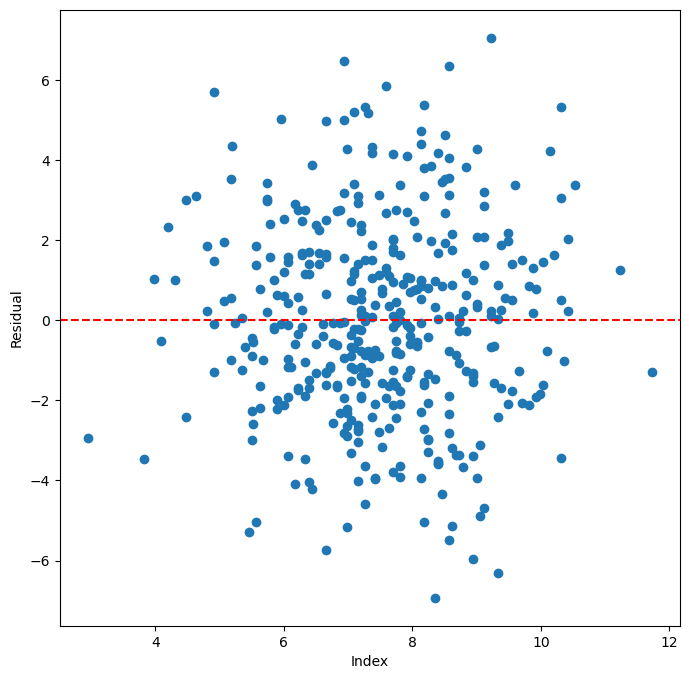

In [12]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(result2.fittedvalues,result2.resid)
ax.set_xlabel("Index")
ax.set_ylabel("Residual")
ax.axhline(0,c="r",ls="--");

Text(0, 0.5, 'Leverage')

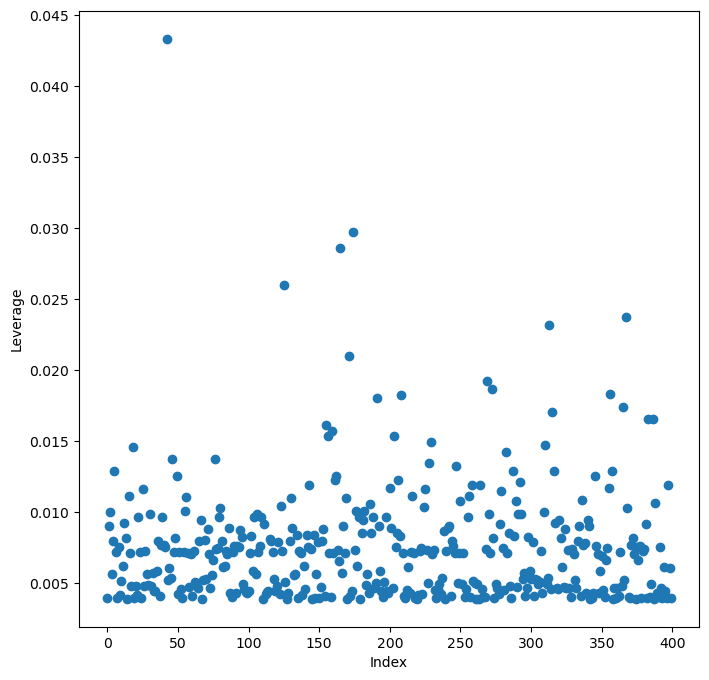

In [13]:

infl = result2.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]),infl.hat_matrix_diag)
ax.set_xlabel("Index")
ax.set_ylabel("Leverage")


Max leverage: 0.0433 at index 42
Max |studentized residual|: 2.892 at index 376

High-leverage points (h_ii > 0.015): 20
Outliers (|studentized residual| > 3): 0


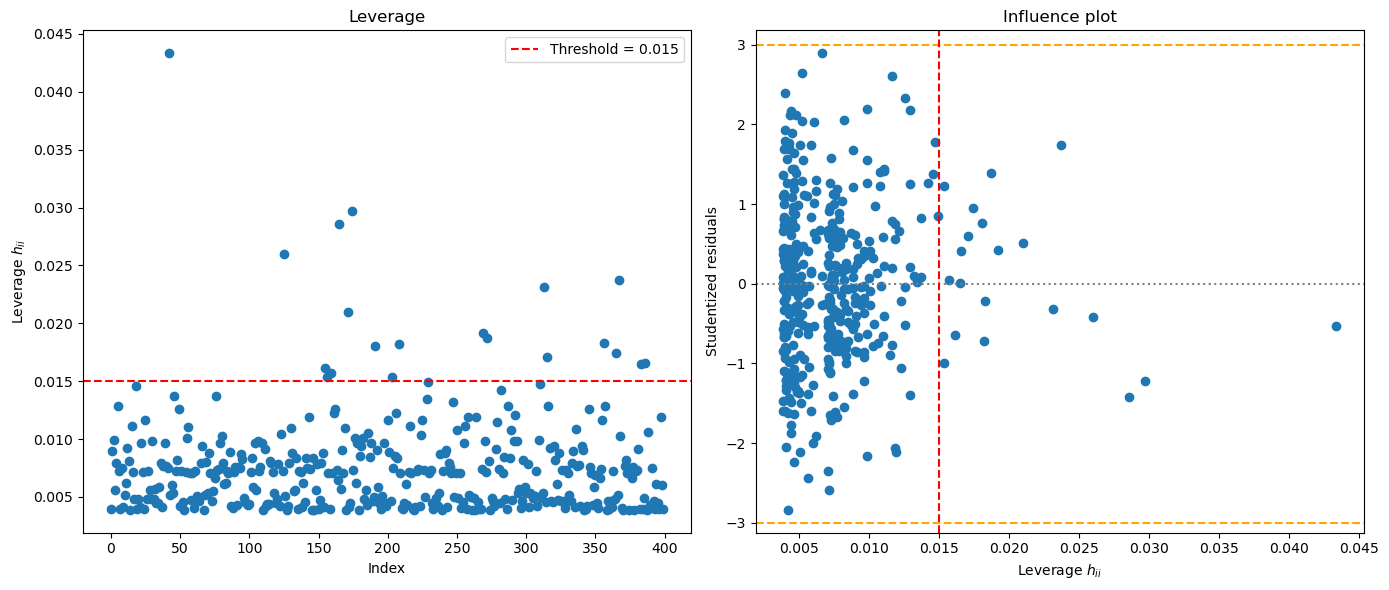

In [14]:

# Compute influence diagnostics
infl = result2.get_influence()
leverage = infl.hat_matrix_diag
student_resid = infl.resid_studentized_external

# Threshold for high leverage
n = result2.nobs
p = result2.df_model
threshold = 2 * (p + 1) / n

# Two side-by-side plots
fig, axes = subplots(1, 2, figsize=(14, 6))

# (1) Leverage vs index
axes[0].scatter(np.arange(int(n)), leverage)
axes[0].axhline(threshold, color='red', linestyle='--',
                label=f'Threshold = {threshold:.3f}')
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Leverage $h_{ii}$")
axes[0].set_title("Leverage")
axes[0].legend()

# (2) Studentized residuals vs leverage
axes[1].scatter(leverage, student_resid)
axes[1].axhline( 3, color='orange', linestyle='--')
axes[1].axhline(-3, color='orange', linestyle='--')
axes[1].axhline( 0, color='gray',   linestyle=':')
axes[1].axvline(threshold, color='red', linestyle='--')
axes[1].set_xlabel("Leverage $h_{ii}$")
axes[1].set_ylabel("Studentized residuals")
axes[1].set_title("Influence plot")

fig.tight_layout()

# Print the most extreme points
idx_max_lev = np.argmax(leverage)
idx_max_res = np.argmax(np.abs(student_resid))

print(f"Max leverage: {leverage[idx_max_lev]:.4f} at index {idx_max_lev}")
print(f"Max |studentized residual|: {student_resid[idx_max_res]:.3f} at index {idx_max_res}")
print(f"\nHigh-leverage points (h_ii > {threshold:.3f}): "
      f"{np.sum(leverage > threshold)}")
print(f"Outliers (|studentized residual| > 3): "
      f"{np.sum(np.abs(student_resid) > 3)}")